# 03 — Hierarchical Bayesian model and posterior figures
Fits the hierarchical Bayesian model and exports posterior summaries and figures.

In [3]:
# !pip -q install pandas numpy matplotlib pymc arviz openpyxl
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
from scipy.special import expit
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = "/content/outputs"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
TAB_DIR = os.path.join(PROJECT_ROOT, "tables")
INT_DIR = os.path.join(PROJECT_ROOT, "intermediate")
for d in [PROJECT_ROOT, FIG_DIR, TAB_DIR, INT_DIR]:
    os.makedirs(d, exist_ok=True)

DATA_PATH = "analytic_cohort_for_modeling.csv"
COL_HOSPITAL = "hospital_hash"
COL_BRAND = "brand_hash"
COL_AGE = "age_at_year"
COL_CM = "cm_count"
COL_DT = "total_downtime_hours"
COL_Y = "high_downtime_t_plus_1"
TEST_SIZE_HOSPITALS = 0.25
RANDOM_STATE = 42

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.9598,0.1216,-1.1884,-0.7284,0.0021,0.0013,3489.0379,5976.6307,1.0005
sigma_alpha,0.6119,0.0955,0.4477,0.7968,0.0012,0.0007,5774.2027,12126.0843,1.0011
beta[age],0.0444,0.0243,-0.0006,0.0907,0.0001,0.0001,36945.7268,31399.6852,1.0001
beta[cm],0.3431,0.0320,0.2837,0.4036,0.0002,0.0001,26479.3049,30003.0436,1.0001
beta[dt_log1p],0.1539,0.0307,0.0953,0.2113,0.0002,0.0001,26786.8544,30710.9419,1.0002


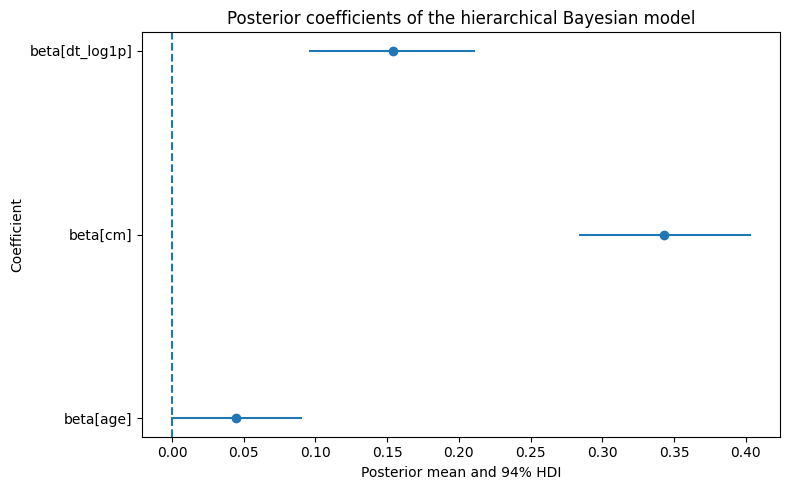

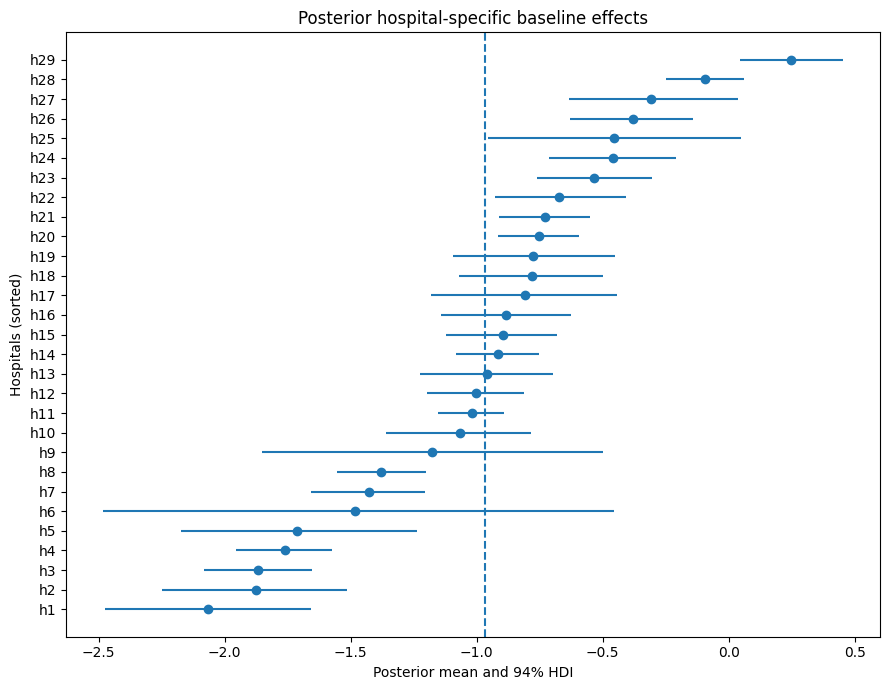

Done.


In [6]:
FINAL_RUN = True
if FINAL_RUN:
    DRAWS, TUNE, CHAINS = 10000, 4000, 4
else:
    DRAWS, TUNE, CHAINS = 2000, 2000, 4

df = pd.read_csv(DATA_PATH).copy()
df["dt_log1p"] = np.log1p(df[COL_DT])
split_obj = np.load(os.path.join(INT_DIR, "empirical_split_indices.npz"))
train_df = df.iloc[split_obj["train_idx"]].reset_index(drop=True)
test_df = df.iloc[split_obj["test_idx"]].reset_index(drop=True)

feature_cols = [COL_AGE, COL_CM, "dt_log1p"]
y_train = train_df[COL_Y].astype(int).values
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

train_hosp_codes, train_hosp_uniques = pd.factorize(train_df[COL_HOSPITAL])
n_hosp = len(train_hosp_uniques)

scaler_bayes = StandardScaler()
Xb_train = scaler_bayes.fit_transform(X_train)
Xb_test = scaler_bayes.transform(X_test)

coords = {"obs_id": np.arange(len(train_df)), "hospital": np.arange(n_hosp), "coef": ["age", "cm", "dt_log1p"]}
with pm.Model(coords=coords) as hb_model:
    hosp_idx = pm.Data("hosp_idx", train_hosp_codes, dims="obs_id")
    X_data = pm.Data("X", Xb_train, dims=("obs_id", "coef"))
    mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=2.0)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1.0)
    alpha_h_raw = pm.Normal("alpha_h_raw", mu=0.0, sigma=1.0, dims="hospital")
    alpha_h = pm.Deterministic("alpha_h", mu_alpha + alpha_h_raw * sigma_alpha, dims="hospital")
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="coef")
    eta = alpha_h[hosp_idx] + pm.math.dot(X_data, beta)
    p = pm.Deterministic("p", pm.math.sigmoid(eta), dims="obs_id")
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_train, dims="obs_id")
    idata = pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, target_accept=0.9, random_seed=RANDOM_STATE, progressbar=True)

summary = az.summary(idata, var_names=["mu_alpha", "sigma_alpha", "beta"], round_to=4)
display(summary)
summary.to_csv(os.path.join(TAB_DIR, "table_bayesian_posterior_summary.csv"))
with open(os.path.join(TAB_DIR, "table_bayesian_posterior_summary.tex"), "w") as f:
    f.write(summary.reset_index().rename(columns={"index": "Parameter"}).to_latex(index=False, float_format="%.4f"))

coef_summary = az.summary(idata, var_names=["beta"], round_to=4).reset_index().rename(columns={"index": "Parameter"})
plt.figure(figsize=(8,5))
ypos = np.arange(len(coef_summary))
plt.errorbar(coef_summary["mean"], ypos,
             xerr=[coef_summary["mean"] - coef_summary["hdi_3%"], coef_summary["hdi_97%"] - coef_summary["mean"]],
             fmt="o")
plt.axvline(0, linestyle="--")
plt.yticks(ypos, coef_summary["Parameter"])
plt.xlabel("Posterior mean and 94% HDI"); plt.ylabel("Coefficient")
plt.title("Posterior coefficients of the hierarchical Bayesian model")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_bayesian_coefficients.png"), dpi=300)
plt.show()

alpha_summary = az.summary(idata, var_names=["alpha_h"], round_to=4).reset_index().rename(columns={"index": "hospital_param"})
alpha_summary = alpha_summary.sort_values("mean").reset_index(drop=True)
plt.figure(figsize=(9,7))
ypos = np.arange(len(alpha_summary))
plt.errorbar(alpha_summary["mean"], ypos,
             xerr=[alpha_summary["mean"] - alpha_summary["hdi_3%"], alpha_summary["hdi_97%"] - alpha_summary["mean"]],
             fmt="o")
plt.axvline(alpha_summary["mean"].mean(), linestyle="--")
plt.yticks(ypos, [f"h{i+1}" for i in range(len(alpha_summary))])
plt.xlabel("Posterior mean and 94% HDI"); plt.ylabel("Hospitals (sorted)")
plt.title("Posterior hospital-specific baseline effects")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_bayesian_random_intercepts.png"), dpi=300)
plt.show()

posterior = idata.posterior
mu_alpha_draws = posterior["mu_alpha"].stack(sample=("chain", "draw")).values
beta_draws = posterior["beta"].stack(sample=("chain", "draw")).transpose("sample", "coef").values
eta_test_draws = mu_alpha_draws[:, None] + beta_draws @ Xb_test.T
p_bayes = expit(eta_test_draws).mean(axis=0)
pd.DataFrame({COL_Y: test_df[COL_Y].values, "Hierarchical Bayesian model": p_bayes, COL_HOSPITAL: test_df[COL_HOSPITAL].values}).to_csv(
    os.path.join(INT_DIR, "bayesian_test_predictions.csv"), index=False
)
print("Done.")

,Model,AUROC,AUPRC,Brier,Top-10 capture,Top-5 capture
0,Hierarchical Bayesian model,0.659408,0.279318,0.132522,0.223054,0.119760
1,Logistic regression,0.659147,0.275486,0.131354,0.224551,0.104790
2,Gradient boosting,0.655827,0.278391,0.131505,0.252994,0.122754
3,Age + maintenance heuristic,0.654704,0.259263,0.135553,0.206587,0.109281
4,Age-only heuristic,0.551451,0.172849,0.167969,0.116766,0.052395


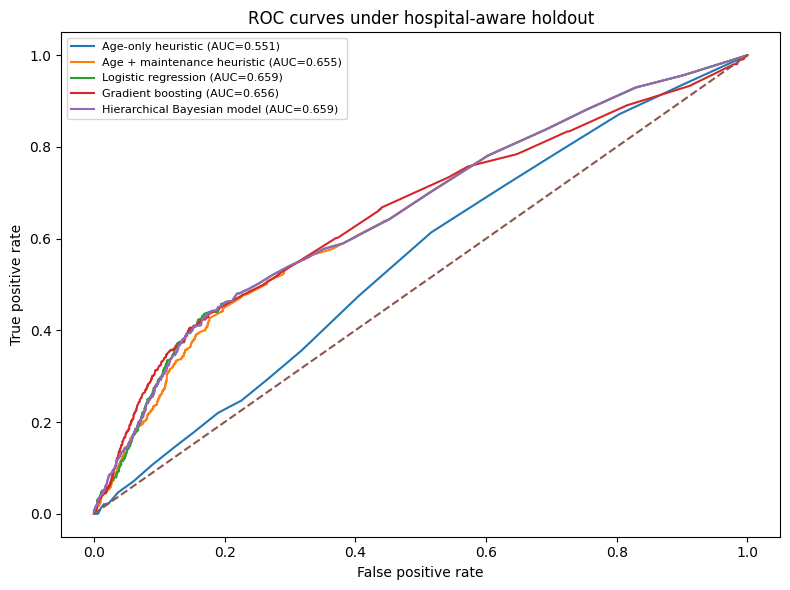

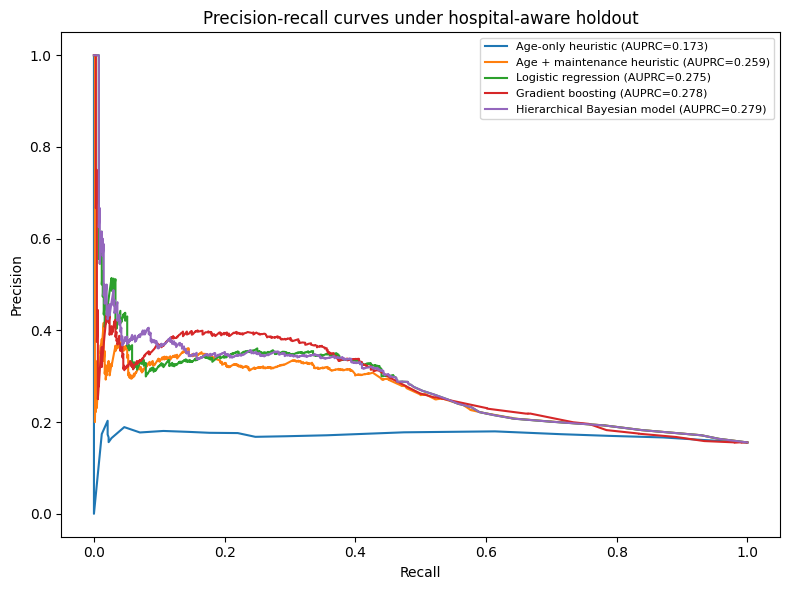

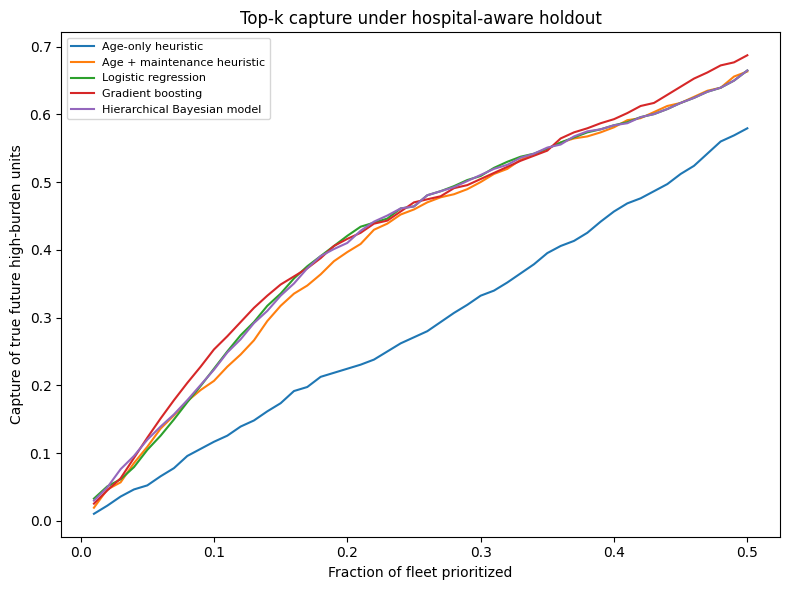

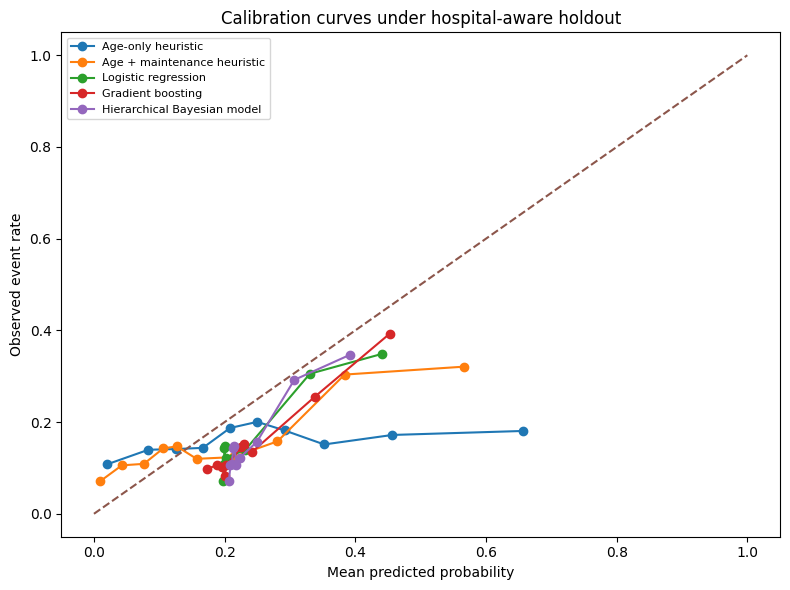

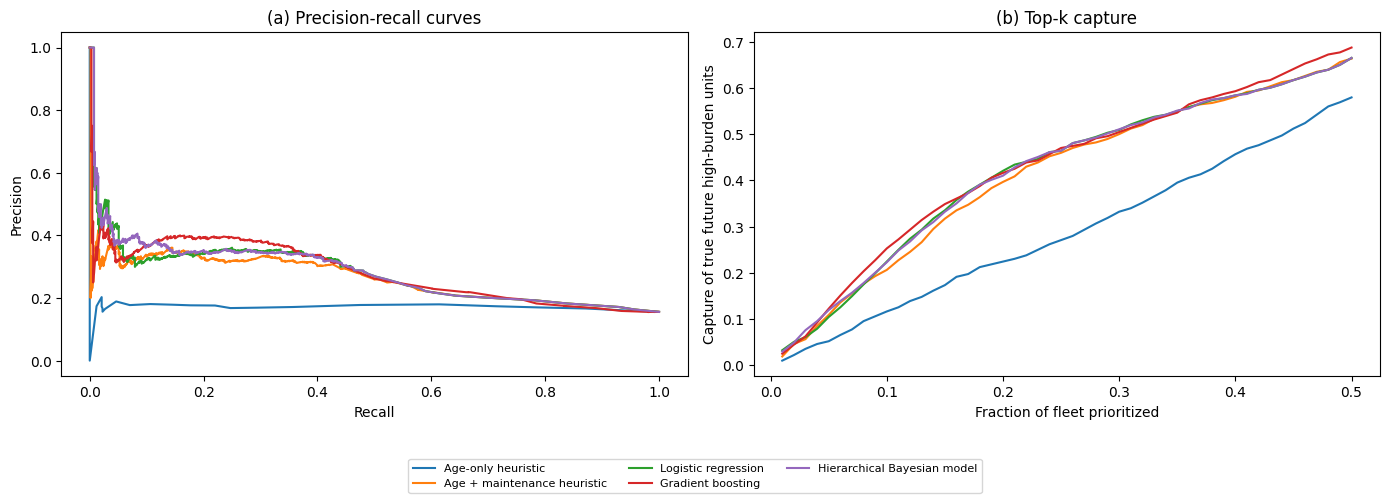

Final predictive table and figures including Bayesian model were exported to:
/content/outputs/tables
/content/outputs/figures


In [5]:
# ============================================================
# Final empirical predictive figures including Bayesian model
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve

# Load benchmark and Bayesian predictions
benchmark_pred = pd.read_csv(os.path.join(INT_DIR, "benchmark_test_predictions.csv"))
bayes_pred = pd.read_csv(os.path.join(INT_DIR, "bayesian_test_predictions.csv"))

# Combine predictions
final_pred = benchmark_pred.copy()
final_pred["Hierarchical Bayesian model"] = bayes_pred["Hierarchical Bayesian model"].values

y_test = final_pred[COL_Y].astype(int).values

model_order = [
    "Age-only heuristic",
    "Age + maintenance heuristic",
    "Logistic regression",
    "Gradient boosting",
    "Hierarchical Bayesian model",
]

risk_scores = {
    model_name: final_pred[model_name].values
    for model_name in model_order
}

def top_k_capture(y, p, k_frac=0.10):
    n = len(y)
    k = max(1, int(np.ceil(k_frac * n)))
    idx = np.argsort(-p)[:k]
    positives = y.sum()
    if positives == 0:
        return np.nan
    return y[idx].sum() / positives

# ------------------------------------------------------------
# Final predictive performance table
# ------------------------------------------------------------

perf_rows = []

for model_name, p in risk_scores.items():
    perf_rows.append({
        "Model": model_name,
        "AUROC": roc_auc_score(y_test, p),
        "AUPRC": average_precision_score(y_test, p),
        "Brier": brier_score_loss(y_test, p),
        "Top-10 capture": top_k_capture(y_test, p, 0.10),
        "Top-5 capture": top_k_capture(y_test, p, 0.05),
    })

final_perf_df = (
    pd.DataFrame(perf_rows)
    .sort_values("AUROC", ascending=False)
    .reset_index(drop=True)
)

display(final_perf_df)

final_perf_df.to_csv(
    os.path.join(TAB_DIR, "table_predictive_performance_final_with_bayes.csv"),
    index=False
)

with open(os.path.join(TAB_DIR, "table_predictive_performance_final_with_bayes.tex"), "w") as f:
    f.write(final_perf_df.to_latex(index=False, float_format="%.3f"))

# ------------------------------------------------------------
# ROC curves including Bayesian model
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for model_name, p in risk_scores.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves under hospital-aware holdout")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_roc_curves_final_with_bayes.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Precision-recall curves including Bayesian model
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for model_name, p in risk_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, p)
    auprc = average_precision_score(y_test, p)
    plt.plot(recall, precision, label=f"{model_name} (AUPRC={auprc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves under hospital-aware holdout")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_pr_curves_final_with_bayes.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Top-k capture including Bayesian model
# ------------------------------------------------------------

k_fracs = np.linspace(0.01, 0.50, 50)

plt.figure(figsize=(8, 6))

for model_name, p in risk_scores.items():
    captures = [top_k_capture(y_test, p, k) for k in k_fracs]
    plt.plot(k_fracs, captures, label=model_name)

plt.xlabel("Fraction of fleet prioritized")
plt.ylabel("Capture of true future high-burden units")
plt.title("Top-k capture under hospital-aware holdout")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_topk_capture_final_with_bayes.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Calibration curves including Bayesian model
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for model_name, p in risk_scores.items():
    frac_pos, mean_pred = calibration_curve(
        y_test,
        p,
        n_bins=10,
        strategy="quantile"
    )
    plt.plot(mean_pred, frac_pos, marker="o", label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration curves under hospital-aware holdout")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_calibration_curves_final_with_bayes.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Optional: compact combined figure for main manuscript
# PR curve + Top-k capture
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Precision-recall
for model_name, p in risk_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, p)
    axes[0].plot(recall, precision, label=model_name)

axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("(a) Precision-recall curves")

# Panel B: Top-k capture
for model_name, p in risk_scores.items():
    captures = [top_k_capture(y_test, p, k) for k in k_fracs]
    axes[1].plot(k_fracs, captures, label=model_name)

axes[1].set_xlabel("Fraction of fleet prioritized")
axes[1].set_ylabel("Capture of true future high-burden units")
axes[1].set_title("(b) Top-k capture")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(os.path.join(FIG_DIR, "figure_predictive_prioritization_final_with_bayes.png"), dpi=300)
plt.show()

print("Final predictive table and figures including Bayesian model were exported to:")
print(TAB_DIR)
print(FIG_DIR)